# `expeditions.csv`:

This notebook explores the Himalayan Expeditions dataset, which contains detailed records of 10,512 expeditions to Himalayan peaks. The dataset includes 57 variables capturing a wide range of expedition characteristics, such as peak information, team composition, routes, outcomes, and notable events.

While the dataset is comprehensive, not all variables will be relevant for every analysis. Throughout this notebook, we will focus on the most informative features to understand expedition trends, success rates, and risk factors.

**Key variables include:**  
`peak_id`, `peak_name`, `nationality`, `year`, `season`, `host_cntr`, `other_cntrs`, `sponsor`, `leaders`, `rte_1_name`, `rte_2_name`, `rte_3_name`, `rte_4_name`, `team_asc_1`, `team_asc_2`, `team_asc_3`, `team_asc_4`, `is_disputed`, `is_claim`, `is_commercial_rte`, `is_standard_rte`, `other_smts`, `approach`, `bc_arrived`, `bc_left`, `total_days`, `exp_result`, `is_traverse`, `is_ski_snowboard`, `is_parapente`, `term_note`, `summit_day`, `time`, `max_elev_reached`, `summit_days`, `total_mbrs`, `mbrs_summited`, `mbrs_deaths`, `high_camps`, `hired_abc`, `hired_summits`, `hired_deaths`, `rope_fixed`, `is_no_hired_abc`, `is_o2_not_used`, `is_o2_climbing`, `is_o2_descent`, `is_o2_sleeping`, `is_o2_medical`, `is_o2_used`, `is_o2_unkwn`, `had_o2`, `camp_sites`, `accidents`, `achievements`, `agency`, `members`

**Analysis tools:**  
- **Libraries:** `pandas`, `matplotlib.pyplot`, `numpy`  
- **Functions:** `.value_counts()`, `.describe()`

Use these tools to summarize, visualize, and interpret the variables, uncovering patterns and insights about Himalayan expeditions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.feature_selection import f_classif, SelectKBest

In [ ]:
# Load the expeditions data
expeditions_data = pd.read_csv('data/expeditions.csv')

# variable_name = expeditions_data['variable_name']
# print(variable_name.value_counts())         # How many of each unique variable_name occurs?
# variable_name.describe()                    # Prints the total number of rows, how many unique variable_names there are,
#                                             # which variable occurs the most (and how many times)

In [26]:
# Prints the .value_counts() and .describe() for a given column'
column_name = input("Enter a variable name to analyze (e.g., 'peak_id', 'season', etc.): ")

# Check if the column exists in the DataFrame
if column_name in expeditions_data.columns:
    print(".value_counts for" , column_name , ":")
    print(expeditions_data[column_name].value_counts())

    print(".describe for" , column_name , ":")
    print(expeditions_data[column_name].describe())
else:
    print(column_name , "is not a valid column name in the dataset.")

.value_counts for total_mbrs :
total_mbrs
2     1564
1     1522
3     1054
4     1026
5      846
6      829
7      671
8      585
9      436
10     381
11     292
12     250
13     188
14     142
15     131
16      98
17      69
18      56
20      55
0       50
19      48
21      28
22      23
23      20
25      17
27      16
24      16
28      12
34       8
29       6
30       6
31       6
35       5
26       5
36       5
42       3
32       3
37       2
39       2
50       2
49       2
52       2
33       2
48       1
44       1
72       1
47       1
41       1
76       1
40       1
99       1
65       1
62       1
Name: count, dtype: int64
.describe for total_mbrs :
count    10494.000000
mean         5.942920
std          5.410798
min          0.000000
25%          2.000000
50%          5.000000
75%          8.000000
max         99.000000
Name: total_mbrs, dtype: float64


Here are some variable descriptions:

`peak_id` : ID of a peak

`peak_name`: Peak Name

`nationality`: Thr principle nationality of the expedition (main nationality)  

`year`: Expedition year

`season`: Expedition season

`host_cntr`: Country from which ascent has begun

`other_cntrs`: Countries that took part in the expedition (members nationality)  

`sponsor`: Expedition sponsor  
[Are they climbing solo or with an organization?]

`leaders`: Leader/leaders of the expedition  

`rte_1_name`: The first route name (similar for the rest features with the same prefix)  

`rte_2_name`: The second route name

`rte_3_name`: The third route name

`rte_4_name`: The fourth route name

`team_asc_1`: The times that a team ascended for a certain route name (similar for the rest features with the same prefix)  

`is_disputed`: Success Disputed or Unverified  

`is_claim`: Expedition claims that summited, however, without any evidence (probably a lie)  

`is_commercial_rte`: If the expedition was commercial  

`is_standard_rte`: If the route is standard (`S Col-SE Ridge` / `N Col-NE Ridge` / `N Col`)  

`other_smts`: Other peaks summited  

`approach`: Main expedition intermediate points to reach the mountain  

`bc_arrived`: Arrival data at the base camp  

`bc_left`: Departure date from the base camp  

`total_days`: Total number of days spent by the expedition  

`exp_result`: The result of the expedition  

In [3]:
exp_result = expeditions_data['exp_result']
print(exp_result.value_counts())            # How many of each unique exp_result occurs?
exp_result.describe()                       # Prints the total number of rows, number of unique exp_results there are,
                                            # which variable occurs the most (and how many times)

exp_result
Success                       5692
Bad Weather                   1308
Bad Conditions                1109
Illness, AMS                   465
Route Difficulty               439
Other                          316
Accident                       296
Did not Climb                  233
Last of Supplies               220
Success (Subpeak, ForeSmt)     121
Unknown                        106
Lack of Time                    92
Not to Reach BC                 64
Success (Claimed)               21
Attempt Rumored                 12
Name: count, dtype: int64


count       10494
unique         15
top       Success
freq         5692
Name: exp_result, dtype: object

In [4]:
### I started manually adding them into success and not success ###

No_Success = {
    'Bad Weather': 'No_Success',
    'Bad Conditions': 'No_Success',
    'Illness, AMS': 'No_Success',
    'Route Difficulty': 'No_Success',
    'Accident': 'No_Success',
    'Did not Climb': 'No_Success',
    "Last of Supplies": 'No_Success',
    "Lack of Time": 'No_Success',
    "Not to Reach BC": 'No_Success',
}

Success = {
    'Success': 'Success',
    'Success (Subpeak, ForeSmt)': 'Success',
    'Success (Claimed)': 'Success',
}
exp_result1 = exp_result.replace(Success).replace(No_Success)

print(exp_result1.value_counts())            # How many of each unique exp_result1 occurs?
exp_result1.describe()                       # Prints the total number of rows, number of unique exp_result1s there are,
                                             # which variable occurs the most (and how many times)

exp_result
Success            5834
No_Success         4226
Other               316
Unknown             106
Attempt Rumored      12
Name: count, dtype: int64


count       10494
unique          5
top       Success
freq         5834
Name: exp_result, dtype: object

`is_traverse`: If the traverse has been made (?)  

`is_ski_snowboard`: If the descent has been made using ski/snowboard  

`is_parapente`: If the descent has been made using parapente  

`term_note`: Summit termination details/results  

`summit_day`: Day of the summit  (YYYY-MM-DD)

`time`: Summit time  (XX:XX)

`max_elev_reached`: Max elevation reached by the expedition  

`summit_days`: Day of the summit according to total_days feature  

`total_mbrs`: Total number of expedition members that have summited 

`mbrs_summited`: Total number of expedition members that have summited  

In [5]:
mbrs_summited = expeditions_data['mbrs_summited']
print(mbrs_summited.value_counts())         # How many of each unique mbrs_death occurs?
mbrs_summited.describe()                    # Prints the total number of rows, mean, standard deviation,
                                            # minimum, maximum, lower quartile, upper quartile, and median
# MBRS_SUMMITED = []                            # List of Unique mbrs_deaths
# for i in mbrs_summited:
#     if i in MBRS_SUMMITED:
#         continue
#     elif i not in MBRS_SUMMITED:
#         MBRS_SUMMITED.append(i)
# print(len(MBRS_SUMMITED))

mbrs_summited
0     4842
1     1553
2     1374
3      758
4      608
5      396
6      264
7      176
8      141
9      106
10      69
11      49
12      38
14      27
13      24
15      17
16      13
17       7
23       5
20       5
18       4
27       2
24       2
21       2
29       2
22       2
28       2
19       2
32       1
39       1
30       1
25       1
Name: count, dtype: int64


count    10494.000000
mean         1.867257
std          2.894572
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         39.000000
Name: mbrs_summited, dtype: float64

In [6]:
# displays number of deaths per expedition (even when zero) (below)
mbrs_summited = expeditions_data['mbrs_summited']
#print(members_deaths)

# when mbrs_summited != 0 --> number of expeditions that have a summit
mbrs_summited1 = expeditions_data[mbrs_summited != 0]
print('Number of expeditions where summits occur:' , len(mbrs_summited1))

print('Probability that a summit occurs' , len(mbrs_summited1) / len(mbrs_summited))

Number of expeditions where summits occur: 5652
Probability that a summit occurs 0.5385934819897084


`mbrs_deaths`: Total number of expedition members that died  

In [7]:
mbrs_death = expeditions_data['mbrs_deaths']
print(mbrs_death.value_counts())        # How many of each unique mbrs_death occurs?
mbrs_death.describe()                   # Prints the total number of rows, mean, standard deviation,
                                        # minimum, maximum, lower quartile, upper quartile, and median
# mbrs_deaths = []                                  # List of Unique mbrs_deaths
# for i in mbrs_death:
#     if i in mbrs_deaths:
#         continue
#     elif i not in mbrs_deaths:
#         mbrs_deaths.append(i)
# print(len(mbrs_deaths))

mbrs_deaths
0     9931
1      422
2       96
3       26
4        9
5        8
7        1
10       1
Name: count, dtype: int64


count    10494.000000
mean         0.074805
std          0.374835
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: mbrs_deaths, dtype: float64

In [8]:
# displays number of deaths per expedition (even when zero) (below)
members_deaths = expeditions_data['mbrs_deaths']
#print(members_deaths)

# when mbrs_deaths != 0 --> death(s) occured during the expedition
non_zero_deaths = expeditions_data[members_deaths != 0]
print('Number of expeditions where deaths occur:' , len(non_zero_deaths))

print('Probability that a death occurs' , len(non_zero_deaths) / len(members_deaths))

Number of expeditions where deaths occur: 563
Probability that a death occurs 0.05364970459310082


`high_camps`: Number of high camps

`hired_abc`: ?

`hired_summits`: ?

`hired_deaths`: ?

`rope_fixed`: total rope length that has been fixed on the mountain/route  

`is_no_hired_abc`: ?  

`is_o2_not_used`: If O2 has not been used  

`is_o2_climbing`: If O2 has been used during climbing  

`is_o2_descent`: If O2 has been used only on descent  

`is_o2_medical`: If O2 has been used for medical reasons  

`is_o2_unkwn`: It's unknown whether O2 has been used or not  

`had_o2`: O2 has been taken but unused  

`camp_sites`: Expedition camps locations  

`accidents`: Accident description  

`achievements`: Achievement description  

`agency`: Commercial agency name  

`members`: Expedition members (name: `L - Leader`, `S - Summited`, `D - Died`)

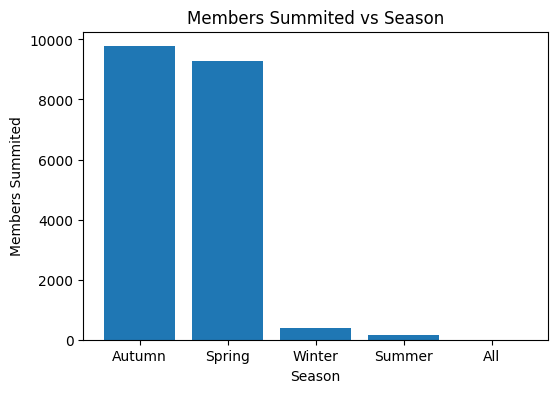

In [17]:
# Group by season and sum the number of members who summited
season_summits = expeditions_data.groupby('season')['mbrs_summited'].sum()

# Sort values (highest summit rate on the left)
season_summits = season_summits.sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(season_summits.index, season_summits.values)

plt.title('Members Summited vs Season')
plt.xlabel('Season')
plt.ylabel('Members Summited')
plt.show()

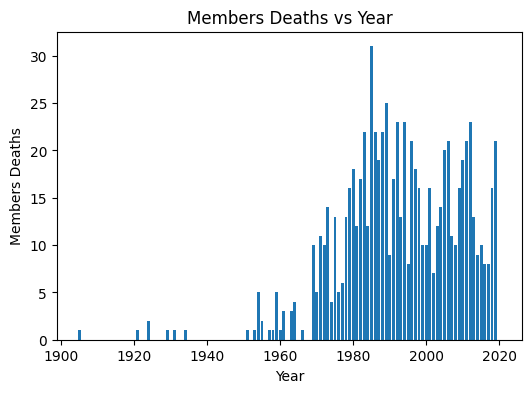

In [10]:
# Group by year and sum the number of members who died
year_deaths = expeditions_data.groupby('year')['mbrs_deaths'].sum()

# Sort values (highest summit rate on the left)
year_deaths = year_deaths.sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(year_deaths.index, year_deaths.values)

plt.title('Members Deaths vs Year')
plt.xlabel('Year')
plt.ylabel('Members Deaths')
plt.show()

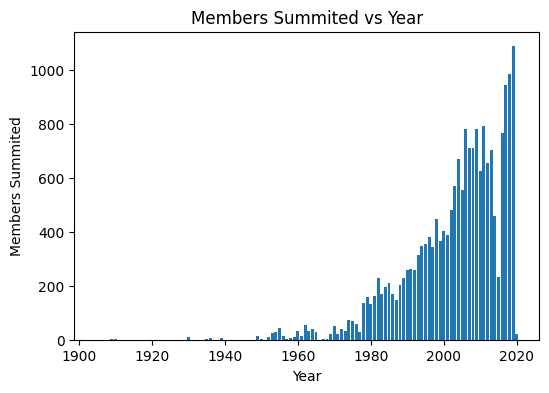

In [22]:
# Group by year and sum the number of members who summited
year_summits = expeditions_data.groupby('year')['mbrs_summited'].sum()

# Sort values (highest summit rate on the left)
year_summits = year_summits.sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(year_summits.index, year_summits.values)

plt.title('Members Summited vs Year')
plt.xlabel('Year')
plt.ylabel('Members Summited')
plt.show()

In [28]:
no_mbrs_summited = expeditions_data[mbrs_summited == 0]
print('Percentage of expeditions where they did not summit:' , len(no_mbrs_summited)/len(mbrs_summited))

Percentage of expeditions where they did not summit: 0.4614065180102916


## Section Summary

This section demonstrates the process of building and evaluating a logistic regression model to predict expedition success based on Himalayan expedition data.

**Key Steps:**
- Data loading and preprocessing, including filtering, feature selection, and one-hot encoding.
- Feature ranking using ANOVA F-test.
- Splitting data into training and testing sets.
- Feature scaling with `StandardScaler`.
- Training a logistic regression model.
- Evaluating model performance using confusion matrix, Peirce Skill Score (PSS), Heidke Skill Score (HSS), classification report, and ROC curve.

The notebook provides both code and visualizations to interpret model results.

In [ ]:
### Data Preparation ###
expeditions = "data/expeditions.csv"
df_raw = pd.read_csv(expeditions)

# Filtering
df = df_raw[df_raw['max_elev_reached'] > 7000].copy()

# Binarize Target Variable
df['success'] = (df['mbrs_summited'] > 0).astype(int)

# Feature Selection & Engineering
# We will DROP 'leaders' and 'members' for now, as they are too complex to encode directly
# We will also DROP 'peak_name' and 'rte_1_name' for now due to high cardinality (high number of unique values)
numerical_features = [
    'year',
    'total_days',
    'max_elev_reached',
    'total_mbrs'
]

# These are features that are already binary (0/1) or can be treated as such.
binary_features = [
    'is_commercial_rte',
    'is_standard_rte',
    'is_o2_climbing'
]

# This is a good candidate for One-Hot Encoding as it has few categories.
categorical_features_low_cardinality = [
    'season'
]

# Combine into the final feature set for now
selected_features = numerical_features + binary_features + categorical_features_low_cardinality
all_cols_to_keep = selected_features + ['success']

# Subset and drop rows with NaN
df_model = df[all_cols_to_keep].dropna()

# One-Hot Encode the Low-Cardinality Categorical Features
# It creates new 0/1 columns for each category (e.g., 'season_Spring', 'season_Autumn').
df_model = pd.get_dummies(df_model, columns=categorical_features_low_cardinality, drop_first=True)

# Separate Features (X) and Target (y)
# 'success' is our target variable
X = df_model.drop('success', axis=1)
y = df_model['success']

# Rank the features
# Calculate F-scores and p-values for these numerical features
# f_classif returns two arrays: F-scores and p-values
f_scores, p_values = f_classif(X, y)

# Create a DataFrame to view the results, then sort by F-score
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'P-Value': p_values
})

# Sort features by F-score in descending order to see the most important ones first
ranked_features = feature_ranking.sort_values(by='F-Score', ascending=False)

print("ANOVA F-test Feature Ranking")
print(ranked_features)

# Split data into training and testing sets
# This prevents information from the test set "leaking" into the training process.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler to normalize the features
scaler = StandardScaler()

# Fit the scaler on the data
# The scaler "learns" the mean and standard deviation from the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same fitted scaler
# It's crucial to only use .transform() here to apply the same scaling rules
X_test_scaled = scaler.transform(X_test)

# Initilize the Logistic Regression Model
# max_iter=1000 allows more training cycles if convergence takes time.
model = LogisticRegression(max_iter=1000)

# Fit the model to the training data
model.fit(X_train_scaled, y_train)

# With the model, predict the test data
y_pred = model.predict(X_test_scaled)

In [ ]:
# Generate the confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")

# Calculate Peirce Skill Score (PSS)
# Also known as True Positive Rate - False Positive Rate
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn) # This is the same as Recall
fpr = fp / (fp + tn)
pss = tpr - fpr
print(f"Peirce Skill Score (PSS): {pss:.2f}")

# Calculate Heidke Skill Score (HSS)
numerator = 2 * (tp * tn - fp * fn)
denominator = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
hss = numerator / denominator

print(f"Heidke Skill Score (HSS): {hss:.2f}")

# Generate a report with precision, recall, and f1-score for each class
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Failure (0)', 'Success (1)']))


# Get the probabilities of predicting a success
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plot the curve
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='Logistic Regression')
display.plot()
plt.title('ROC Curve')
plt.show()